# Stage 3 – EDA, Step 5: Validity Checks

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `03_eda_missing_duplicates.ipynb` (Steps 3 and 4)

---

## Where we are in the EDA

So far we have dealt with three kinds of data problem:

- **Step 2 – wrong target values:** prices of \$0, \$1 and \$2.8 billion. Rule: keep \$100 to \$10,000.
- **Step 3 – absent values:** blanks in parking, laundry and coordinates. Rule: a `"missing"` category and a regional fill.
- **Step 4 – repeated values:** half the listings are copies. Rule: deduplicate on model features + price.

Step 5 deals with the fourth kind: values that are **present, but impossible or implausible**. A value can be filled in and still be wrong. Step 1 already spotted several:

- `sqfeet` of **0**, and a maximum of **8,388,607**. That is exactly 2²³ − 1, a number computers use as a "maximum" placeholder, not a real size;
- **1,100 bedrooms** and **75 bathrooms**;
- **latitude 102**, which cannot exist (latitude stops at 90), and points in the southern hemisphere;
- the `state` column not matching the location (Reno listings labelled `ca`).

Step 2 also left two leads for this step:

- homes **for sale** posted in the rental section, which may also hide inside the valid price range;
- a **heavy lower tail** of rents between about \$100 and \$250, which could be rooms, weekly rates or errors.

---

## Three kinds of validity rule

It helps to separate three kinds of check, because each needs a different level of proof:

1. **Hard limits: physically impossible values.** Latitude above 90, a home of 0 sq ft. No argument is needed; these are errors.
2. **Plausibility limits: possible in theory, but not credible for a rental listing.** 75 bathrooms, a 50,000 sq ft apartment. We choose the limit from the data (counts and real examples), just as we chose the price limits in Step 2.
3. **Consistency checks: each value is fine alone, but the combination is impossible.** Four bedrooms in 250 sq ft; coordinates 1,500 km away from the listing's own Craigslist region. These are the hardest errors to find, because no single column looks wrong.

## Two ways to fix an invalid value

- **Remove the row.** Used when the invalid value is a *core fact* about the listing (its size, bedrooms or bathrooms), or when the listing isn't a monthly rental at all. We can't trust the rest of a row whose basic description is wrong, and these are inputs the user will always type into the prediction system.
- **Set the value to missing and fill it.** Used for coordinates. A wrong map pin doesn't mean the listing is fake. Its region (`region_url`) is still known, so we blank the coordinates and let the Step 3 regional fill replace them.

As before, **nothing is deleted in this notebook**. We measure, decide and record, and at the end we estimate how big the final modelling dataset will be once every rule from Steps 2–5 is applied.

**Which rows are counted?** Counts use **all 384,977 rows**, as in Steps 3 and 4. Each table also shows how many flagged rows are inside the **valid price range**, because those are the rows that would otherwise reach the model.

## 5.0 Setup

The same setup as notebooks 02 and 03: shared helpers and constants from `src/utils.py`, the parquet loaded with `load_raw()`, and `valid`, the Step 2 price rule as a True/False marker per row.

Two small helper functions are defined here because every section uses them:

- **`flag_table(checks)`** takes a dictionary of named checks (each a True/False marker for every row) and builds a table with the number of flagged listings, their % of all rows, and how many of them are inside the valid price range. It's the same kind of threshold table as in Step 2.2.
- **`peek(mask)`** shows a random sample of listings that match a check, with the start of their description. As in Step 2.4, reading real examples is how we tell an error from a genuine unusual listing.

In [16]:
# 5.0 Setup

%load_ext autoreload
%autoreload 2

import re
import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

df_raw = load_raw()
df = df_raw.copy()
valid = df["price"].between(PRICE_MIN, PRICE_MAX)   # Step 2 rule

print(f"All rows:         {len(df):,}")
print(f"Valid-price rows: {len(df[valid]):,}")


def flag_table(checks):
    # One row per check: how many listings it flags, overall and inside the valid price range
    return pd.DataFrame({
        "listings": {name: int(m.sum()) for name, m in checks.items()},
        "%_of_all_rows": {name: m.mean() * 100 for name, m in checks.items()},
        "in_valid_price_range": {name: int((m & valid).sum()) for name, m in checks.items()},
    }).style.format({"listings": "{:,}", "%_of_all_rows": "{:.3f}%", "in_valid_price_range": "{:,}"})


SHOW_COLS = ["price", "type", "sqfeet", "beds", "baths", "region", "state", "description"]

def peek(mask, n=8, cols=SHOW_COLS):
    # Random sample of listings matching mask, with a shortened description
    n = min(n, int(mask.sum()))
    if n == 0:
        print("   (no listings match)")
        return None
    out = df.loc[mask, cols].sample(n, random_state=RANDOM_STATE).copy()
    if "description" in out:
        out["description"] = out["description"].str.slice(0, 100)
    with pd.option_context("display.max_colwidth", 110):
        display(out)

show_obs(4)   # Step 4 findings, to confirm the handover

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
All rows:         384,977
Valid-price rows: 382,494


,step,observation,evidence,decision
0,4-Duplicates,No exact duplicate rows (0); every id is unique,4.1 level 1,Exact-duplicate removal alone would miss the p...
1,4-Duplicates,"46,544 extra copies (12.09%) are reposts: iden...","4.1 level 2, 4.2 example group",Remove reposts before the train/test split
2,4-Duplicates,"191,384 extra copies (49.71%) are identical to...","4.1 level 4, 4.3 largest groups","Deduplicate on model features + price, keeping..."
3,4-Duplicates,"Without deduplication, 58.9% of test rows have...",4.4 leakage simulation,Deduplicate BEFORE splitting to prevent leakag...
4,4-Duplicates,"203,909 listings reuse a photo from another li...",4.1 level 5,Evidence only: different real units can share ...
5,4-Duplicates,Cleaning order matters: fixing values can crea...,Reasoning from Steps 2-5,Step 7 order: price rule -> validity fixes (St...
6,4-Duplicates,Level-4 deduplication removes 50% of valid row...,4.4 rows_before_split,Still ample for all five models; from Step 6 o...


## 5.1 Square footage (`sqfeet`)

**What this cell does:** it shows the extreme quantiles of `sqfeet` (as we did for price in Step 2.1), counts listings at several low and high thresholds, lists the most repeated very large values, and shows real examples from both ends.

**Why we do it:** size is one of the strongest drivers of rent, and one of the inputs a user will type into the prediction system. An impossible size corrupts the most important relationship the model has to learn: the model would see "0 sq ft costs \$1,500" or "8 million sq ft costs \$900" and try to make sense of it.

**What to look for in the output:**

- **Zeros.** Craigslist may store 0 when the poster left the field empty. So a 0 is really a hidden *missing value*, not a tiny home.
- **Placeholder values.** 8,388,607 = 2²³ − 1 is the largest number some systems store in a fixed-size field. If it appears several times, it's a system artefact, not a typo. Other suspicious values are round numbers like 1,000,000.
- **The boundary between real and fake.** Look at the examples just above 5,000 sq ft. Some large houses are genuine (like the luxury homes in Step 2). Listings of 50,000 sq ft with 2 bedrooms are clearly not.

**A useful comparison:** a standard car parking space is about 160 sq ft. A whole home under 100 sq ft is smaller than half a parking space, which is not credible for a rental listing.

In [17]:
# 5.1 sqfeet: extreme quantiles, threshold counts, repeated large values

sq = df["sqfeet"]
quantiles = [0, 0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999, 0.9999, 1]
display(sq.quantile(quantiles).rename("sqfeet").to_frame())

sqft_checks = {
    "sqfeet == 0": sq.eq(0),
    "sqfeet < 100": sq.lt(100),
    "sqfeet < 150": sq.lt(150),
    "sqfeet < 200": sq.lt(200),
    "sqfeet > 5,000": sq.gt(5_000),
    "sqfeet > 10,000": sq.gt(10_000),
    "sqfeet > 20,000": sq.gt(20_000),
    "sqfeet == 8,388,607 (2^23 - 1)": sq.eq(8_388_607),
}
display(flag_table(sqft_checks))

print("Most common sqfeet values above 10,000:")
display(sq[sq > 10_000].value_counts().head(10).rename("listings"))

,sqfeet
0.00,0.00
0.00,25.00
0.01,270.00
0.01,340.00
0.05,536.00
0.50,949.00
0.95,"1,642.00"
0.99,"2,405.00"
0.99,"2,800.00"
1.00,"4,200.00"


,listings,%_of_all_rows,in_valid_price_range
sqfeet == 0,48,0.012%,48
sqfeet < 100,976,0.254%,955
sqfeet < 150,"1,072",0.278%,"1,047"
sqfeet < 200,"1,179",0.306%,"1,154"
"sqfeet > 5,000",273,0.071%,235
"sqfeet > 10,000",82,0.021%,79
"sqfeet > 20,000",35,0.009%,33
"sqfeet == 8,388,607 (2^23 - 1)",1,0.000%,1


Most common sqfeet values above 10,000:


sqfeet
11000      6
50000      5
999999     4
12000      3
20000      3
1019856    2
23000      2
11500      2
13600      2
17951      1
Name: listings, dtype: int64

In [18]:
# 5.1 (cont.) Real examples at both ends

print("Listings under 100 sq ft")
peek(sq.between(1, 99))
print("Listings of 5,001 to 10,000 sq ft")
peek(sq.between(5_001, 10_000))
print("Listings over 10,000 sq ft")
peek(sq.gt(10_000))

# Findings to note: are the small ones rooms, parking spaces, or typos (e.g. 85 instead of 850)?
# Are the 5k-10k ones real large houses? Are the >10k ones all nonsense?

Listings under 100 sq ft


,price,type,sqfeet,beds,baths,region,state,description
310061,1075,condo,35,2,2.00,san marcos,tx,"Lovely 2/2 downstairs condo in super location. Enjoy the convenience of living at the quiet, tree s"
266775,500,house,50,1,1.00,greenville / upstate,sc,Original hard wood floors in living and bedroom. Semi shaded fenced in back yard and large cleaned o
8388,3078,apartment,39,2,1.00,SF bay area,ca,"SEACLIFF APARTMENTS 300 Palmetto Avenue Pacifica, CA 94044 Phone: show contact info Website:"
195137,0,apartment,1,1,1.00,lincoln,ne,"Bedrooms: 1 Bathrooms: 1 Price: $0 Welcome to Homestead Village, apartments for seniors 62+ and dis"
97730,695,house,30,3,1.00,evansville,in,$99 Move in Special !!! Charming 3 bedroom home with New flooring throughout this home as well as a
179056,1195,condo,75,3,2.50,charlotte,nc,"3Bedroom, 2 Â½ Bath. Condo. Comedor. Sala. Aire Central. Calef/ Gas. Estufa. Nevera. Lavaplatos. Pat"
74118,595,apartment,50,1,1.00,columbus,ga,1 Month Free with 13 Month Lease or 2 Weeks Free with 12 Month Lease https://midtownpark.rentals
232673,595,apartment,1,2,1.00,mansfield,oh,All Utilities Paid on the following properties: 146 S Main St. - #3 \t$450 mo./$450


Listings of 5,001 to 10,000 sq ft


,price,type,sqfeet,beds,baths,region,state,description
319109,4800,house,5417,5,3.50,salt lake city,ut,Stunning home in the coveted area of Holladay. Very open floor plan with the main level partially re
153457,440,house,7000,0,3.50,kalamazoo,mi,K College an6d WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDROOM 4 BATH HOME Lease NOW
326322,1100,house,5696,5,4.50,new river valley,va,Great price reduction on this idyllic North Arlington home on quiet street yet minutes to DC!! Beaut
139682,1900,apartment,9999,1,1.00,boston,ma,Amazing 1 bed split. Available 9/1/20. Broker Fee Required. has a kitchen equipped with granite cou
128671,4000,house,5232,5,4.50,new orleans,la,Call Jennifer Today to schedule a private showing! show contact info EZ Qualifying! and LOW down
14042,16010,house,7237,5,5.00,ventura county,ca,"Beautiful 5 bedroom, and additional 2 bonus rooms, 2 offices, library, & 2 bath North Ranch home sit"
7688,15750,house,6000,7,5.00,SF bay area,ca,- Newly renovated home located in the quiet neighborhood of Tobin Clark Estates. - The house is a
15677,8000,house,8112,6,7.00,boulder,co,Rare 6 Bed 7 Bath Tudor Home Offering Panoramic Views & Surrounded by Open Space! Prop


Listings over 10,000 sq ft


,price,type,sqfeet,beds,baths,region,state,description
140006,2175,apartment,11000,2,1.00,boston,ma,"Spacious Two Bedroom Apartment in highly desired part of East Cambridge. We have 1st, 2nd and 3rd"
625,1995,house,17951,3,2.00,reno / tahoe,ca,3 bedrooms/2 bathrooms/2 car garage/game room/1795 sq. ft. approx./no smoking/has AC (brand new unit
95090,350,house,63134,2,1.00,"st louis, MO",il,It comes with a stove and refrigerator. It has a full basement that is freshly painted.
140610,2175,apartment,11000,1,1.00,boston,ma,"Spacious Two Bedroom Apartment in highly desired part of East Cambridge. We have 1st, 2nd and 3rd"
81369,2500,house,10048,3,2.00,hawaii,hi,"House for rent at Woodlawn Dr, is a house in Honolulu, HI 96822. This 1,618 square foot house sits o"
113129,1450,house,18000,3,2.00,lake charles,la,"Home for rent $1,450 per month. $1,000 security deposit Three bedroom two bath large living, sitti"
53876,1100,house,12000,3,1.00,pensacola,fl,"1002 Dominquez St Pensacola, FL 32505$1100.00 / Month---------------------------Interested in this"
222542,1900,house,50000,3,2.00,north dakota,nd,"5 acres seller financing $99,000 with or without a house for rent county board zoned light commerci"


### 5.1 (cont.) The provisional rule for `sqfeet`

Based on the counts and examples above, we set a provisional plausibility range. As in Step 2, **these are starting values: check them against your output** and adjust if the examples suggest otherwise.

- **`SQFT_MIN = 100`:** below this, a whole rental home is not credible (and 0 is really "not entered").
- **`SQFT_MAX = 10,000`:** above this, the examples are placeholders and typos. Genuine homes this large are extremely rare, and they would be above the \$10,000 rent limit anyway.

**Why remove the row rather than fill in a size?** We could guess the size from the number of bedrooms. But size is a core fact the user always provides to the prediction system, and a row whose size is invented teaches the model a relationship that was never observed. The number of affected rows is also small, so removing them costs very little.

In [19]:
# 5.1 (cont.) Provisional sqfeet rule

SQFT_MIN, SQFT_MAX = 100, 10_000
bad_sqft = ~sq.between(SQFT_MIN, SQFT_MAX)
print(f"sqfeet outside {SQFT_MIN:,}-{SQFT_MAX:,}: {bad_sqft.sum():,} listings ({bad_sqft.mean() * 100:.2f}%), "
      f"{(bad_sqft & valid).sum():,} of them in the valid price range")

sqfeet outside 100-10,000: 1,058 listings (0.27%), 1,034 of them in the valid price range


## 5.2 Bedrooms (`beds`)

**What this cell does:** it lists every distinct bedroom count with how many listings have it, then counts listings above several thresholds and shows examples of the very high ones.

**Why we do it:** a full value count is practical here because `beds` has only a few dozen distinct values. It shows the normal range (0 to 4 or 5) and makes the absurd values stand out immediately.

**How to read the output:**

- **0 bedrooms is valid.** It means a **studio**, where the living room is also the bedroom. We keep it.
- **5–8 bedrooms** is possible for large houses, and fairly common in student towns where houses are shared.
- **Above 8** it's worth reading the examples. A listing with 1,100 bedrooms, or 12 bedrooms in 900 sq ft, is a typing error. Sometimes the poster typed the *number of units in the building* or the *size* into the wrong field.

In [20]:
# 5.2 beds: every value, threshold counts, examples

beds = df["beds"]
beds_counts = beds.value_counts().sort_index().rename("listings")
print("Every bedroom count in the data:")
display(beds_counts.to_frame().T)

beds_checks = {
    "beds == 0 (studio, valid)": beds.eq(0),
    "beds > 5": beds.gt(5),
    "beds > 6": beds.gt(6),
    "beds > 8": beds.gt(8),
    "beds > 20": beds.gt(20),
}
display(flag_table(beds_checks))

print("Listings with more than 8 bedrooms")
peek(beds.gt(8))

BEDS_MAX = 8
bad_beds = beds.gt(BEDS_MAX)
print(f"Provisional rule beds <= {BEDS_MAX}: flags {bad_beds.sum():,} listings "
      f"({(bad_beds & valid).sum():,} in the valid price range)")

Every bedroom count in the data:


beds,0,1,2,3,4,5,6,7,8,1000,1100
listings,10978,117226,175513,67037,11575,2324,240,49,31,2,2


,listings,%_of_all_rows,in_valid_price_range
"beds == 0 (studio, valid)","10,978",2.852%,"10,932"
beds > 5,324,0.084%,300
beds > 6,84,0.022%,71
beds > 8,4,0.001%,4
beds > 20,4,0.001%,4


Listings with more than 8 bedrooms


,price,type,sqfeet,beds,baths,region,state,description
89776,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl
235159,550,apartment,250,1000,25.00,youngstown,oh,2 bedroom
37695,1500,land,100,1000,35.00,florida keys,fl,Only one lot available now from now to January 9th and available again in after April 1st One month
90779,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl


Provisional rule beds <= 8: flags 4 listings (4 in the valid price range)


## 5.3 Bathrooms (`baths`)

**What this cell does:** the same approach as for bedrooms: every value with its count, threshold counts, and examples. It also checks two things specific to bathrooms:

- **values that aren't multiples of 0.5** (like 1.25 or 1.7), which shouldn't exist, because U.S. listings count bathrooms in halves;
- **0 bathrooms.**

**Why we do it, and how to read it:**

- **Half values are normal.** A "half bath" is a toilet and sink with no shower, so 1.5 or 2.5 baths is ordinary (Step 1 found them in 10.9% of listings).
- **0 bathrooms is questionable but possible.** It can describe a room in a shared house or a unit with a shared bathroom down the hall. It's not physically impossible, so we look at the examples and count before deciding.
- **Above 8 bathrooms**, as with bedrooms, the examples will show whether they are real mansions or typing errors (Step 1 found 25, 35 and 75).

In [21]:
# 5.3 baths: every value, special checks, examples

baths = df["baths"]
print("Every bathroom count in the data:")
display(baths.value_counts().sort_index().rename("listings").to_frame().T)

baths_checks = {
    "baths == 0": baths.eq(0),
    "baths not a multiple of 0.5": (baths * 2 % 1) != 0,
    "baths > 4": baths.gt(4),
    "baths > 6": baths.gt(6),
    "baths > 8": baths.gt(8),
}
display(flag_table(baths_checks))

print("Listings with 0 bathrooms")
peek(baths.eq(0))
print("Listings with more than 8 bathrooms")
peek(baths.gt(8))

BATHS_MAX = 8
bad_baths = baths.gt(BATHS_MAX)
print(f"Provisional rule baths <= {BATHS_MAX}: flags {bad_baths.sum():,} listings "
      f"({(bad_baths & valid).sum():,} in the valid price range)")

Every bathroom count in the data:


baths,0.00,1.00,1.50,2.00,2.50,3.00,3.50,4.00,4.50,5.00,5.50,6.00,6.50,7.00,7.50,8.00,8.50,25.00,35.00,75.00
listings,3107,198184,27363,134649,13162,5549,1007,1495,231,131,57,26,4,4,2,1,1,1,1,2


,listings,%_of_all_rows,in_valid_price_range
baths == 0,"3,107",0.807%,"3,078"
baths not a multiple of 0.5,0,0.000%,0
baths > 4,461,0.120%,386
baths > 6,16,0.004%,13
baths > 8,5,0.001%,4


Listings with 0 bathrooms


,price,type,sqfeet,beds,baths,region,state,description
30124,900,apartment,670,1,0.00,new haven,ct,Nice sized 1 bedroom apartments in well maintained buildings under $1000. Ask me about our differen
57617,1300,apartment,748,1,0.00,south florida,fl,This quaint community in Boca Raton is centrally located close to 95 and the Boca Town Center Mall!
337654,1500,apartment,1500,1,0.00,seattle-tacoma,wa,"We are renting out 2 rooms out of our beloved hotel, wifi, cable, internet, hot water, utilities all"
230703,989,apartment,959,3,0.00,columbus,oh,"Call show contact info if you have any questions!Located in the middle of shopping, dinning and m"
58507,969,apartment,718,1,0.00,space coast,fl,To schedule a tour We now book our tour appointments online! Please call or text us at show contac
340466,600,apartment,900,3,0.00,appleton-oshkosh-FDL,wi,Remodeled apartments some with new kitchens
276422,825,apartment,910,1,0.00,jackson,tn,LUXURIOUS AMENITIES AT WOODS OF POST HOUSE APARTMENTS!Lose yourself in a relaxing afternoon by our s
56953,1975,apartment,843,1,0.00,south florida,fl,This prime downtown Delray Beach location is like no other! If you are looking for a fun and excitin


Listings with more than 8 bathrooms


,price,type,sqfeet,beds,baths,region,state,description
37695,1500,land,100,1000,35.00,florida keys,fl,Only one lot available now from now to January 9th and available again in after April 1st One month
235159,550,apartment,250,1000,25.00,youngstown,oh,2 bedroom
89776,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl
37586,12000000,apartment,9000,7,8.50,florida keys,fl,"MANSION IN THE SKY!!! Breathtaking oceanfront 9,000 square foot, 7 bedroom, 8.5 bathrooms 2-story Pe"
90779,2449,apartment,1000,1100,75.00,chicago,il,Furnished or Unfurnished Units Includes Parking Newly Remodeled Short or Long Term Leases availabl


Provisional rule baths <= 8: flags 5 listings (4 in the valid price range)


## 5.4 Do size, bedrooms and bathrooms fit together?

This is the first **consistency check**: values that pass their own limits but make no sense together.

**Check 1 – space per room.** We divide the size by the number of rooms, counting the bedrooms plus one living area: `sqfeet / (beds + 1)`. U.S. building codes generally require a habitable room to be at least **70 sq ft**, so a home with less than 70 sq ft per room can't physically contain the rooms it claims. For example, 3 bedrooms in 200 sq ft gives 50 sq ft per room.

**Check 2 – bathrooms vs bedrooms.** Homes rarely have many more bathrooms than bedrooms. A 1-bedroom apartment with 5 bathrooms most likely has the two numbers swapped or mistyped. We flag listings where `baths > beds + 3`, a generous margin that still allows, for example, a 2-bed house with 3.5 baths.

**Why only rows that passed 5.1–5.3?** Rows already failing the size, bedroom or bathroom limits will be removed anyway. Checking only the remaining rows shows how many *extra* errors the consistency rules catch. That's the real value of this step.

**How to read the output:** the counts show how common each problem is, and the examples show whether flagged rows really are errors. If check 2 mostly flags genuine large houses, we'd keep it as a warning only rather than a removal rule.

In [22]:
# 5.4 Consistency between size, bedrooms and bathrooms

passes_basic = ~bad_sqft & ~bad_beds & ~bad_baths
sqft_per_room = df["sqfeet"] / (df["beds"] + 1)

tiny_rooms = passes_basic & sqft_per_room.lt(70)
too_many_baths = passes_basic & (df["baths"] > df["beds"] + 3)

display(flag_table({
    "under 70 sq ft per room": tiny_rooms,
    "baths > beds + 3": too_many_baths,
}))

print("Listings with under 70 sq ft per room")
peek(tiny_rooms)
print("Listings with baths > beds + 3")
peek(too_many_baths)

# Findings to note: are the tiny-room rows typos in sqfeet (e.g. 90 instead of 900)?
# Are the many-bath rows swapped fields, or genuine?

,listings,%_of_all_rows,in_valid_price_range
under 70 sq ft per room,122,0.032%,121
baths > beds + 3,32,0.008%,32


Listings with under 70 sq ft per room


,price,type,sqfeet,beds,baths,region,state,description
39349,1750,townhouse,200,3,3.00,ft myers / SW florida,fl,Beautiful townhouse in Bristol Pines available March 1st. All tile on first floor and carpet on seco
105617,150,house,180,4,3.00,baton rouge,la,"***Read before contacting me*** ***Updated as of 01/02/2019*** ***All utilities, cable+internet inc"
111075,200,house,100,4,2.00,"kansas city, MO",ks,I have fully furnished rooms for rent on a weekly or biweekly basis with no lease or background chec
259293,659,apartment,133,1,1.00,york,pa,"Looking for a roommate for November - it's a 3 bedroom, 2 bathroom apartment and you would lease out"
5955,2650,apartment,100,3,1.50,SF bay area,ca,"Townhouse: 3 Bed, 1.5 Bath, 1199 sq.ft., (1 Full bath, 1 Half bath) Address: 38627 Cherry lane Unit"
87908,875,house,100,3,1.00,champaign urbana,il,House on quiet traffic circle in pleasant neighborhood **Special deals possible for Section 8 and Ho
178738,855,house,260,3,3.00,charlotte,nc,3BR/3BA - Dutch Colonial Eastover Home next to Colonial Park! Single family home on quiet street wit
351267,968,apartment,171,2,2.00,huntsville / decatur,al,"Contact Me today for more information! We have beautiful updated units! We have 1, 2, and 3 bedroom"


Listings with baths > beds + 3


,price,type,sqfeet,beds,baths,region,state,description
332274,425,apartment,190,2,6.00,bellingham,wa,Check out www.sternberghall.org. We have a small dormitory with 14 sleeping rooms (most of them are
153875,440,house,7000,0,3.50,kalamazoo,mi,Luxury Student Living K College and WMU BEAUTIFUL 10-12 BEDROOMS 4 BATH HOME Lease NOW for August
308157,895,apartment,1182,1,5.00,san antonio,tx,"Welcome to Park Greene Townhomes, and escape the bustle of professional life and enter a private vis"
153973,440,house,7000,0,3.50,kalamazoo,mi,"Luxury Student Living BEAUTIFUL 12 BEDROOMS 4 BATH HOME Lease NOW for August 18, 2020 for a Student"
153496,440,house,7000,0,3.50,kalamazoo,mi,K College an6d WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDROOM 4 BATH HOME Lease NOW
153547,440,house,7000,0,3.50,kalamazoo,mi,Amazing Student Rental Home K College and WMU Students Luxury Student Living BEAUTIFUL 10 to 12 BEDR
332277,425,apartment,190,2,6.00,bellingham,wa,Check out www.sternberghall.org. We have a small dormitory with 14 sleeping rooms (most of them are
308739,895,apartment,1182,1,5.00,san antonio,tx,"Welcome to Park Greene Townhomes, and escape the bustle of professional life and enter a private vis"


## 5.5 Coordinates outside the United States

**What this cell does:** it checks every located listing against a simple box around U.S. territory:

- **latitude 18° to 72°**, from the south of Hawaii and Puerto Rico up to northern Alaska;
- **longitude −180° to −65°**, from the western Aleutian Islands in Alaska to the east coast of Maine.

Anything outside the box is broken into the likely cause:

- **latitude above 90 or below −90:** impossible anywhere on Earth (hard limit);
- **negative latitude:** southern hemisphere, e.g. the −43.5 found in Step 1;
- **positive longitude:** eastern hemisphere, e.g. the 172.63 found in Step 1;
- **other:** on Earth, but outside the U.S.

It also tests whether a simple **sign flip** would put the point back inside the U.S. For example, a longitude typed as 119.8 instead of −119.8.

**Why we do it:** coordinates feed the model directly (as numbers), and they're also used to fill missing coordinates in Step 3. A point in the Indian Ocean would distort both.

**The decision, and why we don't "repair" sign flips:** even if flipping a sign puts a point inside the U.S., we can't be sure it's the *right* point. The safer fix is to set the coordinates to missing and let the Step 3 regional fill place the listing at its region's centre. That's always roughly right, because the region is known.

In [23]:
# 5.5 Coordinates outside a U.S. bounding box

lat, lon = df["lat"], df["long"]
located = lat.notna()
LAT_RANGE, LON_RANGE = (18, 72), (-180, -65)

in_us = lat.between(*LAT_RANGE) & lon.between(*LON_RANGE)
outside_us = located & ~in_us

coord_checks = {
    "outside U.S. box (all causes)": outside_us,
    "|latitude| > 90 (impossible)": located & lat.abs().gt(90),
    "negative latitude (southern hemisphere)": located & lat.lt(0),
    "positive longitude (eastern hemisphere)": located & lon.gt(0),
    "fixable by flipping one sign": outside_us & ((-lat).between(*LAT_RANGE) & lon.between(*LON_RANGE)
                                                  | lat.between(*LAT_RANGE) & (-lon).between(*LON_RANGE)),
}
display(flag_table(coord_checks))

print("Listings with coordinates outside the U.S.")
peek(outside_us, cols=["price", "type", "region", "state", "lat", "long", "description"])

,listings,%_of_all_rows,in_valid_price_range
outside U.S. box (all causes),262,0.068%,262
|latitude| > 90 (impossible),4,0.001%,4
negative latitude (southern hemisphere),7,0.002%,7
positive longitude (eastern hemisphere),241,0.063%,241
fixable by flipping one sign,243,0.063%,243


Listings with coordinates outside the U.S.


,price,type,region,state,lat,long,description
364971,835,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 2 Baths: 2 Sqft: 960 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364828,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364715,835,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 2 Baths: 2 Sqft: 960 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364637,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364241,890,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
364503,840,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 1 Baths: 1 Sqft: 730 Rent: $835 We canât wait to welcome you home to Harbin Pointe
364673,855,apartment,fayetteville,ar,36.22,94.12,We canât wait to welcome you home to Harbin Pointe Apartments. To ensure you can find a home that
365063,840,apartment,fayetteville,ar,36.22,94.12,Details: Beds: 1 Baths: 1 Sqft: 660 Rent: $840 We canât wait to welcome you home to Harbin Pointe


## 5.6 Coordinates far from their own region

This is the second **consistency check**, and it catches errors the box in 5.5 misses: a point that is *inside* the U.S., but in the wrong place. For example, a listing on the Denver Craigslist site whose pin is in Florida.

**What this cell does:**

1. For every Craigslist site (`region_url`), it finds the **centre** of its listings: the median latitude and median longitude of all its listings that passed 5.5. The median is used because a few wrong pins can't drag it away, unlike the mean.
2. For every listing, it calculates the **distance in kilometres** between its pin and its region's centre.
3. It shows the distribution of these distances and counts listings beyond 100, 250, 500 and 1,000 km.

**How the distance is calculated:** the **haversine formula** gives the distance between two points on a sphere (the Earth), using their latitudes and longitudes. It's the standard "as the crow flies" distance. A plain Pythagoras calculation on degrees would be wrong, because one degree of longitude is about 111 km at the equator but much less near the poles.

**How to read the output:** most listings should be within a few tens of kilometres of their region centre. Some Craigslist regions are genuinely large ("eastern montana", "southwest TX", "hawaii" across several islands), so distances of 200–400 km can be real. Beyond **500 km** a pin is almost certainly wrong for its region, which is the provisional cut-off.

**Leakage note:** in the final pipeline, the region centres will be computed from the **training data only**, as in Step 3. Here we use all rows, because we're only measuring how common the problem is.

Distance from region centre (km), located listings inside the U.S.:


,km
0.50,8.17
0.90,34.75
0.99,139.51
1.00,"1,285.95"
1.00,"6,910.32"


,listings,%_of_all_rows,in_valid_price_range
more than 100 km from region centre,"5,872",1.525%,"5,790"
more than 250 km from region centre,"1,796",0.467%,"1,766"
more than 500 km from region centre,827,0.215%,814
"more than 1,000 km from region centre",527,0.137%,526


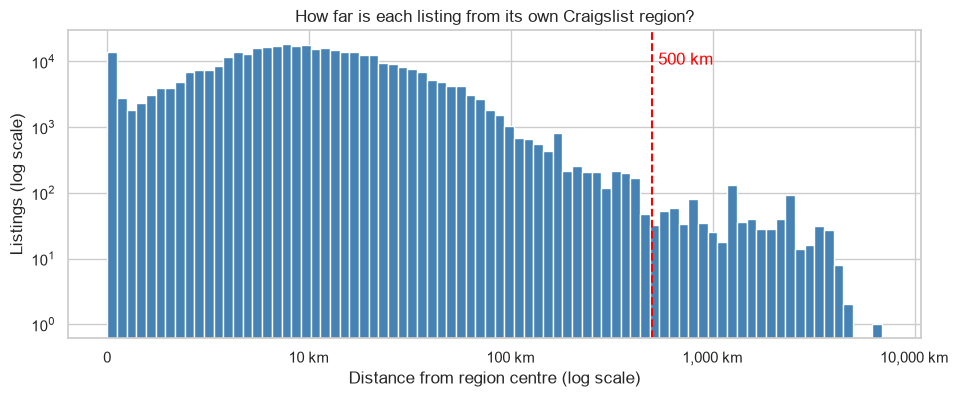

Listings more than 500 km from their region centre


,price,region,state,lat,long,description
110049,400,sioux city,ia,29.49,-94.92,"Fully furnished kitchen, 1 bedroom 1 bath apartment, all linens, just bring your clothes and tooth b"
353223,1550,mobile,al,34.05,-118.21,"138 N. Soto St, Los Angeles, CA, 90033 *NO parking on-site, only street parking. Live in a huge a"
153143,469,jackson,mi,32.31,-90.20,"Location: 1240 Lawnview Pl - Jackson, MS 39203 Rental Information:$469 /Month |1 Bedroom 1 Bath |"
159904,1780,minneapolis / st paul,mn,28.88,-81.21,"Welcome home to RiZE at Opus Park Apartments, a brand-new upscale mid-rise residential community fea"
91425,1050,la salle co,il,40.49,-104.71,3N- TR IN E2 SE4; REFERRED TO AS THE SE4 NE4 SE4 AS WELL AS THE NE4 SE4 SE4 LESS THE SOUTH 9' OF EAS
136984,1700,frederick,md,47.07,-122.39,"This 3 bedroom, 2.5 bath home has 1,370 square feet of living space. Leases signed in this state may"
376564,1350,los angeles,ca,37.96,-121.33,Charming guest house with private entrance attached to a large deck with an amazing view. Rent inc
66909,650,albany,ga,42.70,-73.90,2bed 2bath moost fabolous and nice Apartment for rent This brand new property is unlike any other i


In [24]:
# 5.6 Distance from each listing to its region's centre

def haversine_km(lat1, lon1, lat2, lon2):
    # Great-circle distance in km between two points given in degrees
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

good_coords = located & in_us
centres = df[good_coords].groupby("region_url")[["lat", "long"]].median()
centre_lat = df["region_url"].map(centres["lat"])
centre_lon = df["region_url"].map(centres["long"])

dist_km = pd.Series(np.nan, index=df.index)
dist_km[good_coords] = haversine_km(lat[good_coords], lon[good_coords],
                                    centre_lat[good_coords], centre_lon[good_coords])

print("Distance from region centre (km), located listings inside the U.S.:")
display(dist_km.quantile([0.5, 0.9, 0.99, 0.999, 1]).rename("km").to_frame())

display(flag_table({f"more than {d:,} km from region centre": dist_km.gt(d) for d in [100, 250, 500, 1_000]}))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(dist_km.dropna() + 1), bins=80, color="steelblue")
ax.set_yscale("log")
ax.axvline(np.log10(501), color="red", linestyle="--")
ax.text(np.log10(501) + 0.03, ax.get_ylim()[1] * 0.3, "500 km", color="red")
ax.set_xticks(range(5))
ax.set_xticklabels(["0", "10 km", "100 km", "1,000 km", "10,000 km"])
ax.set(xlabel="Distance from region centre (log scale)", ylabel="Listings (log scale)",
       title="How far is each listing from its own Craigslist region?")
save_fig("05_distance_from_region_centre")
plt.show()

FAR_KM = 500
far_from_region = dist_km.gt(FAR_KM)
print("Listings more than 500 km from their region centre")
peek(far_from_region, cols=["price", "region", "state", "lat", "long", "description"])

## 5.7 What does the `state` column really mean?

Step 1 noticed that listings from Reno (in Nevada) carry `state = ca`. This cell checks why.

**What this cell does:**

1. It counts how many different `state` values each Craigslist site (`region_url`) has. If every site has exactly **one** state, then `state` is a label of the **site**, copied onto every listing from it, not the property's real state.
2. It shows the Reno site as an example: its state label and the centre of its listings. The centre is near 39.5° N, 119.8° W, which is Reno, Nevada.

**Why it matters:** if `state` describes the *site*, it can be "wrong" for the property. The Reno/Tahoe site covers both Nevada and California, and Craigslist filed it under California. That's not a data-entry error we can fix row by row, and it isn't harmful: all listings from one site consistently get the same label. But we must describe it honestly in the report. `state` means "the state the Craigslist site belongs to", and exact location is carried by `region_url` and the coordinates.

In [25]:
# 5.7 Is state a property of the site or of the listing?

states_per_site = df.groupby("region_url")["state"].nunique()
print("Number of different state labels per Craigslist site:")
display(states_per_site.value_counts().sort_index().rename("sites").to_frame().T)

reno_sites = [u for u in centres.index if "reno" in u]
if reno_sites:
    reno = df[df["region_url"].isin(reno_sites)]
    print(f"\nReno site(s): {reno_sites}")
    print(f"State label(s): {sorted(reno['state'].unique())}")
    print(f"Centre of its listings: lat {centres.loc[reno_sites[0], 'lat']:.2f}, "
          f"long {centres.loc[reno_sites[0], 'long']:.2f}  (Reno, Nevada is about 39.5, -119.8)")

Number of different state labels per Craigslist site:


state,1,2
sites,399,14



Reno site(s): ['https://reno.craigslist.org']
State label(s): ['ca', 'nv']
Centre of its listings: lat 39.53, long -119.78  (Reno, Nevada is about 39.5, -119.8)


## 5.8 Homes for sale hiding in the rental data

Step 2 found listings that are **homes for sale**, not rentals, such as manufactured homes at \$78,500 with a separate "lot rent". Those were above \$10,000, so the price rule already removes them. But a cheap sale listing (an old mobile home for \$6,000, or a monthly *loan payment*) could sit **inside** the valid price range and look like a normal rent.

**What this cell does:** it searches every description for wording that signals a sale and reports, for each pattern:

- how many listings match (all rows, and in the valid price range);
- their median price, compared with the overall median;
- what share of them are **manufactured homes**, the type most often sold this way.

The patterns are **regular expressions**: small search rules. `\b` means "word boundary", so `\bfor sale\b` finds "for sale" as whole words but not inside other words. The search is case-insensitive because the text is converted to lower case first.

**Two patterns are included only for comparison, not as sale evidence:**

- **"rent to own"** is a rental arrangement: the tenant pays rent, part of which may go towards buying later. The monthly price *is* a rent.
- **"lot rent"** often appears in manufactured-home parks, even for homes that are rented.

**How to read the output:** a pattern is a good removal rule only if its examples really are sales. "For sale" can occasionally appear innocently ("furniture for sale", "house for sale or rent"), so the next cell shows each match **in context**, the words around it, so you can judge.

In [26]:
# 5.8 Search descriptions for sale wording

desc = df["description"].fillna("").str.lower()
overall_median = df.loc[valid, "price"].median()

sale_patterns = {
    "for sale": r"\bfor sale\b",
    "down payment": r"\bdown ?payment\b",
    "purchase / sale / asking price": r"\b(?:purchase|sale|sales|asking) price\b",
    "owner / in-house financing": r"\b(?:owner|in[- ]house) financ",
    "rent to own (comparison only)": r"\brent[- ]to[- ]own\b",
    "lot rent (comparison only)": r"\blot rent\b",
}

pattern_hits = {name: desc.str.contains(rx, regex=True) for name, rx in sale_patterns.items()}
rows = []
for name, hit in pattern_hits.items():
    in_valid = hit & valid
    rows.append({
        "pattern": name,
        "listings": int(hit.sum()),
        "in_valid_price_range": int(in_valid.sum()),
        "median_price_valid": df.loc[in_valid, "price"].median(),
        "manufactured_%": (df.loc[in_valid, "type"] == "manufactured").mean() * 100 if in_valid.any() else np.nan,
    })
sale_table = pd.DataFrame(rows).set_index("pattern")
print(f"Overall median valid price: ${overall_median:,.0f}   |   "
      f"manufactured share overall: {(df.loc[valid, 'type'] == 'manufactured').mean() * 100:.1f}%")
sale_table.style.format({"listings": "{:,}", "in_valid_price_range": "{:,}",
                         "median_price_valid": "${:,.0f}", "manufactured_%": "{:.1f}%"}, na_rep="-")

Overall median valid price: $1,040   |   manufactured share overall: 1.1%


,listings,in_valid_price_range,median_price_valid,manufactured_%
pattern,,,,
for sale,794,732,"$1,250",29.2%
down payment,826,783,"$1,085",23.2%
purchase / sale / asking price,319,314,"$1,290",34.4%
owner / in-house financing,180,169,"$1,050",26.6%
rent to own (comparison only),"1,900","1,886",$806,4.2%
lot rent (comparison only),418,403,$795,95.5%


### 5.8 (cont.) Reading the matches in context

**What this cell does:** it combines the four sale patterns (not the two comparison patterns) into one **strong sale rule**. Then, for a random sample of matching listings inside the valid price range, it shows the words around the match. Seeing "…3 bed 2 bath home **for sale**, \$5,000 down…" makes it obvious the price isn't a monthly rent, while "…washer and dryer **for sale** by previous tenant…" would be a false alarm.

**How to decide:** if most examples are genuine sales, the strong rule becomes a removal rule. If you see many false alarms from one pattern, drop that pattern from `STRONG_SALE` and re-run.

In [27]:
# 5.8 (cont.) The strong sale rule, with matches shown in context

STRONG_SALE = r"\bfor sale\b|\bdown ?payment\b|\b(?:purchase|sale|sales|asking) price\b|\b(?:owner|in[- ]house) financ"
sale_listing = desc.str.contains(STRONG_SALE, regex=True)

def in_context(text, pattern=STRONG_SALE, width=70):
    m = re.search(pattern, text)
    if not m:
        return ""
    start, end = max(m.start() - width, 0), m.end() + width
    return "..." + text[start:end].replace("\n", " ") + "..."

sample = df[sale_listing & valid].sample(min(10, int((sale_listing & valid).sum())), random_state=RANDOM_STATE)
context = sample[["price", "type", "region", "state"]].copy()
context["match_in_context"] = desc.loc[sample.index].apply(in_context)
with pd.option_context("display.max_colwidth", 200):
    display(context)

print(f"Strong sale rule flags {sale_listing.sum():,} listings, {(sale_listing & valid).sum():,} in the valid price range")

,price,type,region,state,match_in_context
228420,745,house,cleveland,oh,"...ry, there are terrific programs for you as well!! features include a down payment grant, closing costs paid for you, special tax abatement, low interes..."
368616,1500,apartment,bakersfield,ca,...>recently touched up 3 bedroom 2 bath home on a sleepy cul de sac lot for sale. this home features freshly cleaned carpets and new interior paint. t...
267067,500,house,greenville / upstate,sc,...have you wanted to buy a home but couldn't come up with enough of a down payment for a loan or couldn't get approved for a loan? then give rent to own...
257933,1100,house,scranton / wilkes-barre,pa,"...for sale or lease by owner 1711 luzerne st, west scranton. 2 bed, 1 tile b..."
377865,1550,townhouse,modesto,ca,...as maintained by the association with space for gardening if desired asking price for rent is $1550 per month or best offer. deposit will be $1200. uti...
28995,1800,apartment,new haven,ct,"...otos & listings or visit www.seaburyhill.com to search for properties for sale in new haven, the shoreline &; surrounding towns..."
258865,832,manufactured,york,pa,...brand new 2020 manufactured home for sale! move-in ready! lot rent for this home is at $425 including sewer an...
359877,1700,apartment,phoenix,az,"...my client just purchased the property and pictures are relfecting the for sale sign because we are using them from the for sale listing. call, text ..."
341238,1100,house,kenosha-racine,wi,".... $1,100.00 for two people - others additional or best offer. the for sale sign will be removed and the property will be taken off the market if..."
28933,1100,house,new haven,ct,"...must be employed, must have minimum 550 credit score, must have small down payment, must be owner occupied (sorry, no investors unless you are prequalif..."


Strong sale rule flags 1,794 listings, 1,691 in the valid price range


## 5.9 The heavy lower tail: rents of \$100–\$249

Step 2's Q-Q plot showed more very cheap rents than a normal shape would predict. This cell asks: **what are these listings?** There are three likely explanations, and each needs a different response:

1. **Weekly prices.** Some motels and extended-stay places advertise "\$199 per week". Entered as the monthly price, that's wrong by a factor of about 4.3.
2. **Rooms and shared housing.** "Private room for rent, \$225". This is a real monthly rent, but for a *room*, not a whole home.
3. **Genuinely cheap housing,** such as an old trailer in a rural area.

**What this cell does:** it searches the descriptions for weekly-price and room/shared wording, and compares **how often each appears in the \$100–\$249 band vs in all valid listings**. If weekly wording is, say, 10 times more common among these cheap listings than overall, that strongly suggests many of them are weekly prices.

It also computes **price per square foot** (`price / sqfeet`) for the cheap band vs all listings. A whole 900 sq ft home for \$150 gives \$0.17 per sq ft, far below any normal rent. That signals a wrong price or wrong size rather than a real bargain.

**How to read the output:** the "times more common" column is the key number. Values well above 1 mean that kind of listing is concentrated in the cheap band.

In [28]:
# 5.9 What are the $100-$249 listings?

low_band = valid & df["price"].between(PRICE_MIN, 249)
print(f"Listings priced ${PRICE_MIN}-$249: {low_band.sum():,} ({low_band.sum() / valid.sum() * 100:.2f}% of valid rows)")

wording = {
    "weekly price": r"\bweekly\b|\bper week\b|/ ?week\b|/ ?wk\b|\ba week\b",
    "room / shared / roommate": r"\broom for rent\b|\bprivate room\b|\bshared\b|\broommate",
    "deposit / move-in special": r"\bdeposit\b|\bmove[- ]in special",
}
rows = []
for name, rx in wording.items():
    hit = desc.str.contains(rx, regex=True)
    share_low = hit[low_band].mean() * 100
    share_all = hit[valid].mean() * 100
    rows.append({"wording": name, "%_in_$100-249": share_low, "%_in_all_valid": share_all,
                 "times_more_common": share_low / share_all if share_all > 0 else np.nan})
display(pd.DataFrame(rows).set_index("wording")
          .style.format({"%_in_$100-249": "{:.1f}%", "%_in_all_valid": "{:.1f}%", "times_more_common": "{:.1f}x"}))

ppsf = df["price"] / df["sqfeet"].where(df["sqfeet"] > 0)
print("Price per sq ft (median):")
print(f"   $100-$249 band: ${ppsf[low_band].median():.2f}")
print(f"   all valid rows: ${ppsf[valid].median():.2f}")

weekly_low = low_band & desc.str.contains(wording["weekly price"], regex=True)
print("\nCheap listings that mention weekly pricing")
peek(weekly_low)
print("Other cheap listings")
peek(low_band & ~weekly_low)

Listings priced $100-$249: 694 (0.18% of valid rows)


,%_in_$100-249,%_in_all_valid,times_more_common
wording,,,
weekly price,72.2%,2.1%,34.0x
room / shared / roommate,1.9%,5.6%,0.3x
deposit / move-in special,46.1%,26.1%,1.8x


Price per sq ft (median):
   $100-$249 band: $0.58
   all valid rows: $1.12

Cheap listings that mention weekly pricing


,price,type,sqfeet,beds,baths,region,state,description
222750,200,house,940,1,1.00,northern panhandle,oh,"one bedroom house, all utilities included, cable offered, No pets. in Moundsville, WV 26041. $200"
76833,175,apartment,300,1,1.00,macon / warner robins,ga,OK...so you are in a tough situation trying to make your rental payments every month. If only you co
237102,199,apartment,280,1,1.00,oklahoma city,ok,"Do You need a fully furnished apartment for 7 days, or a month or more? **Regular room just $199+ ta"
191283,125,manufactured,1200,3,1.00,winston-salem,nc,Extra nice 3 Bedroom 1 Bath mobile home. Located on Brown Street in Lexington - Convenient to Walma
111388,190,apartment,320,1,1.00,"kansas city, MO",ks,PROMOTIONAL RATE $190+TAX (Single Occupancy) -For new rentals only. This rate is not valid for curr
271484,170,manufactured,1000,2,2.00,chattanooga,tn,If your looking for a nice quiet Neighborhood where everyone respects everyone 2/2 great place to
237456,199,apartment,280,1,1.00,oklahoma city,ok,"Do You need a fully furnished apartment for 7 days, or a month or more? **Regular room just $199+ ta"
170027,245,apartment,475,0,1.00,jackson,ms,We now have a great weekly special at Extended Studio Hotel starting at $245.00. All of our rooms h


Other cheap listings


,price,type,sqfeet,beds,baths,region,state,description
60965,160,condo,950,1,1.00,st augustine,fl,"BEACH RENTERS!! Come and stay in our Beautiful, OCEANFRONT property located in the heart of Ponte V"
234208,246,house,1576,3,2.00,toledo,oh,"Sitting on a large corner lot on a cul-de-sac, this home is bedrooms,bathrooms,formal living/dining"
111669,190,apartment,320,1,1.00,"kansas city, MO",ks,"PH: show contact info $190+Tax _weekly for Single Person only. Flat Screen TV with HD channels,"
253624,244,house,1350,3,1.00,philadelphia,pa,Fantastic Single Family Home! This home will Accommodate All Family Needs! Hugh Living Room with For
190875,112,apartment,758,1,1.00,wilmington,nc,VIEW OUR WEBSITE: http://www.reserveatforesthills.com Lease today at The Reserve at Forest Hills.
264028,244,house,1241,2,2.00,columbia,sc,"One of a kind custom built home is grand and opulent, no expense spared. Gorgeous iron Cantera entry"
6994,120,house,2000,3,2.00,santa barbara,ca,Escape to the country 2000 sq ft adobe ranch house on 40 acres enjoy hiking in nearby Pinnacles nati
34648,210,house,1928,3,1.00,delaware,de,Beautiful home with lots of character in this very desirable neighborhood. To be sold as is but it w


## 5.10 Putting it together: how big will the final dataset be?

**What this cell does:** it combines every rule from Steps 2–5 and applies them **in the order decided in Step 4**, to estimate the final modelling dataset:

1. **Price rule** (Step 2): keep \$100 to \$10,000.
2. **Validity rules** (Step 5), in two groups:
   - *remove the row:* size outside 100–10,000 sq ft, more than 8 beds or baths, under 70 sq ft per room, strong sale wording, or a weekly price under \$250;
   - *blank the coordinates* (the listing is kept): outside the U.S. box or more than 500 km from its region.
3. **Deduplication** (Step 4): one row per group of identical model features + price.

It shows the result as a **funnel**: the number of rows left after each stage.

**Why the order matters:** coordinates are blanked *before* deduplication. Two copies of a listing, one with a correct pin and one with a broken pin, become identical once the broken pin is blanked and regionally filled, so deduplication then correctly treats them as one listing. Deduplicating first would keep both.

**Note on "baths > beds + 3":** it's shown in the table but **not** included in the removal rules, because it's a warning sign rather than proof. Include it only if the 5.4 examples convinced you those rows are errors.

This is still an **estimate**. The real cleaning function, written once and reused, comes in Step 7. But it tells us now whether we're about to lose too much data, while it's still easy to rethink a rule.

Rows each rule affects, inside the valid price range


,listings,%_of_all_rows,in_valid_price_range
"sqfeet outside 100-10,000","1,058",0.275%,"1,034"
beds > 8,4,0.001%,4
baths > 8,5,0.001%,4
under 70 sq ft per room,122,0.032%,121
strong sale wording,"1,794",0.466%,"1,691"
weekly price under $250,501,0.130%,501
coordinates outside U.S.,262,0.068%,262
coordinates > 500 km from region,827,0.215%,814
(warning only) baths > beds + 3,32,0.008%,32


,rows,removed_at_this_stage,%_of_raw_remaining
1. Raw data,"384,977",0,100.0%
2. After price rule (Step 2),"382,494","2,483",99.4%
3. After validity rules (Step 5),"379,158","3,336",98.5%
4. After deduplication (Step 4),"190,221","188,937",49.4%


Coordinates blanked (then filled regionally) in 1,068 kept listings


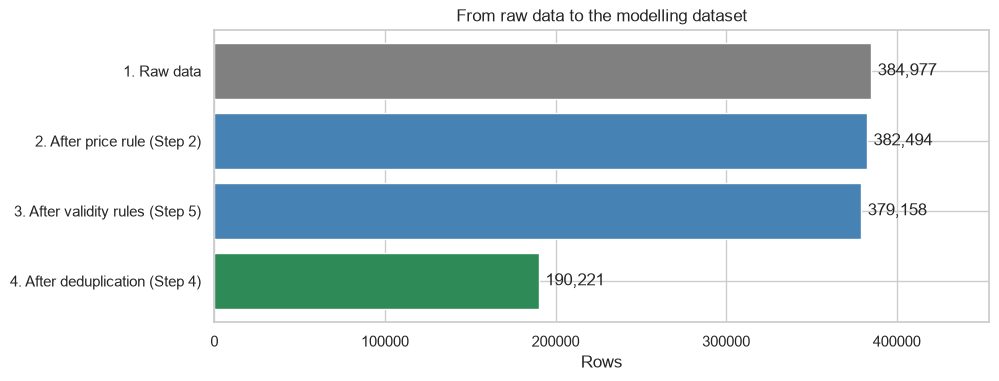

In [29]:
# 5.10 Combined rules and the data funnel

BINARY_COLS = ["cats_allowed", "dogs_allowed", "smoking_allowed",
               "wheelchair_access", "electric_vehicle_charge", "comes_furnished"]
MODEL_FEATURES = ["region_url", "state", "type", "sqfeet", "beds", "baths", *BINARY_COLS,
                  "laundry_options", "parking_options", "lat", "long"]

remove_rules = {
    f"sqfeet outside {SQFT_MIN}-{SQFT_MAX:,}": bad_sqft,
    f"beds > {BEDS_MAX}": bad_beds,
    f"baths > {BATHS_MAX}": bad_baths,
    "under 70 sq ft per room": tiny_rooms,
    "strong sale wording": sale_listing,
    "weekly price under $250": weekly_low,
}
blank_coord_rules = {
    "coordinates outside U.S.": outside_us,
    f"coordinates > {FAR_KM} km from region": far_from_region,
}

print("Rows each rule affects, inside the valid price range")
display(flag_table({**remove_rules, **blank_coord_rules, "(warning only) baths > beds + 3": too_many_baths}))

remove_any = pd.concat(remove_rules, axis=1).any(axis=1)
blank_coords = pd.concat(blank_coord_rules, axis=1).any(axis=1)

stage_price = df[valid]
stage_valid = df[valid & ~remove_any].copy()
stage_valid.loc[blank_coords[stage_valid.index], ["lat", "long"]] = np.nan
stage_dedup = stage_valid.drop_duplicates(subset=MODEL_FEATURES + ["price"])

funnel = pd.Series({
    "1. Raw data": len(df),
    "2. After price rule (Step 2)": len(stage_price),
    "3. After validity rules (Step 5)": len(stage_valid),
    "4. After deduplication (Step 4)": len(stage_dedup),
}, name="rows").to_frame()
funnel["removed_at_this_stage"] = (-funnel["rows"].diff()).fillna(0).astype(int)
funnel["%_of_raw_remaining"] = funnel["rows"] / len(df) * 100
display(funnel.style.format({"rows": "{:,}", "removed_at_this_stage": "{:,}", "%_of_raw_remaining": "{:.1f}%"}))
print(f"Coordinates blanked (then filled regionally) in {int(blank_coords[stage_valid.index].sum()):,} kept listings")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh(funnel.index[::-1], funnel["rows"][::-1], color=["seagreen", "steelblue", "steelblue", "grey"])
for i, v in enumerate(funnel["rows"][::-1]):
    ax.text(v + len(df) * 0.01, i, f"{v:,}", va="center")
ax.set_xlim(0, len(df) * 1.18)
ax.set(xlabel="Rows", title="From raw data to the modelling dataset")
save_fig("05_data_funnel")
plt.show()

## 5.11 Log the Step 5 observations

As in the earlier notebooks, `clear_obs("5")` removes older Step 5 entries first, and the numbers are filled in from your results. After you've checked the examples and confirmed the provisional limits, we'll move them into `src/utils.py` (just as we did with the price limits after Step 2), so the cleaning function in Step 7 uses exactly the same values.

In [30]:
# 5.11 Log the observations

clear_obs("5")

def n_in_valid(mask):
    return f"{int(mask.sum()):,} listings ({int((mask & valid).sum()):,} in the valid price range)"

log_obs("5-Validity",
        f"sqfeet: {int(sq.eq(0).sum()):,} zeros and {int(sq.eq(8_388_607).sum())} at the 2^23-1 placeholder; "
        f"outside {SQFT_MIN}-{SQFT_MAX:,} sq ft: {n_in_valid(bad_sqft)}",
        "5.1 quantiles, threshold counts, repeated values, examples",
        f"Remove rows with sqfeet outside {SQFT_MIN}-{SQFT_MAX:,} (0 means 'not entered'; size is a core user input)")

log_obs("5-Validity",
        f"beds up to {int(beds.max()):,}; above {BEDS_MAX}: {n_in_valid(bad_beds)}; 0 beds = studio (valid)",
        "5.2 value counts and examples",
        f"Remove rows with beds > {BEDS_MAX}")

log_obs("5-Validity",
        f"baths up to {baths.max():g}; above {BATHS_MAX}: {n_in_valid(bad_baths)}; "
        f"{int(baths.eq(0).sum()):,} listings with 0 baths; half-baths normal",
        "5.3 value counts and examples",
        f"Remove rows with baths > {BATHS_MAX}; keep 0 baths (shared-bathroom units) and half-baths")

log_obs("5-Validity",
        f"Under 70 sq ft per room (sqfeet / (beds + 1)): {n_in_valid(tiny_rooms)}; "
        f"baths > beds + 3: {n_in_valid(too_many_baths)}",
        "5.4 consistency checks and examples",
        "Remove physically impossible size/room combinations; baths > beds + 3 kept as a warning only")

log_obs("5-Validity",
        f"Coordinates outside the U.S.: {n_in_valid(outside_us)}; more than {FAR_KM} km from their "
        f"region centre: {n_in_valid(far_from_region)}",
        "5.5 bounding-box checks, 5.6 haversine distances",
        "Set these coordinates to missing and use the Step 3 regional fill; region centres from training data only")

log_obs("5-Validity",
        f"Each Craigslist site has {states_per_site.max()} state label(s) at most; e.g. the Reno site is labelled "
        f"'ca' although Reno is in Nevada",
        "5.7 states per site, Reno example",
        "Interpret state as 'state of the Craigslist site'; exact location comes from region_url and coordinates")

log_obs("5-Validity",
        f"Strong sale wording ('for sale', down payment, sale/asking price, owner financing): {n_in_valid(sale_listing)}",
        "5.8 pattern table and matches in context",
        "Remove listings with strong sale wording (not monthly rents); 'rent to own' is kept as a rental")

log_obs("5-Validity",
        f"{int(low_band.sum()):,} listings priced $100-$249; {int(weekly_low.sum()):,} of them mention weekly pricing",
        "5.9 wording comparison, price per sq ft, examples",
        "Remove weekly-priced listings under $250 (price is not monthly); other cheap listings kept")

log_obs("5-Validity",
        f"Estimated modelling dataset: {len(df):,} raw -> {len(stage_price):,} after price rule -> "
        f"{len(stage_valid):,} after validity rules -> {len(stage_dedup):,} after deduplication",
        "5.10 data funnel",
        "Order in Step 7: price rule -> validity rules (coordinates blanked) -> deduplication -> stratified split")

show_obs(5)

,step,observation,evidence,decision
0,5-Validity,sqfeet: 48 zeros and 1 at the 2^23-1 placehold...,"5.1 quantiles, threshold counts, repeated valu...","Remove rows with sqfeet outside 100-10,000 (0 ..."
1,5-Validity,"beds up to 1,100; above 8: 4 listings (4 in th...",5.2 value counts and examples,Remove rows with beds > 8
2,5-Validity,baths up to 75; above 8: 5 listings (4 in the ...,5.3 value counts and examples,Remove rows with baths > 8; keep 0 baths (shar...
3,5-Validity,Under 70 sq ft per room (sqfeet / (beds + 1)):...,5.4 consistency checks and examples,Remove physically impossible size/room combina...
4,5-Validity,Coordinates outside the U.S.: 262 listings (26...,"5.5 bounding-box checks, 5.6 haversine distances",Set these coordinates to missing and use the S...
5,5-Validity,Each Craigslist site has 2 state label(s) at m...,"5.7 states per site, Reno example",Interpret state as 'state of the Craigslist si...
6,5-Validity,"Strong sale wording ('for sale', down payment,...",5.8 pattern table and matches in context,Remove listings with strong sale wording (not ...
7,5-Validity,694 listings priced $100-$249; 501 of them men...,"5.9 wording comparison, price per sq ft, examples",Remove weekly-priced listings under $250 (pric...
8,5-Validity,"Estimated modelling dataset: 384,977 raw -> 38...",5.10 data funnel,Order in Step 7: price rule -> validity rules ...


---

## What's next: Step 6 – Outliers and feature distributions

Step 5 removed values that are **impossible**. Step 6 looks at values that are **possible but unusual**: the difference between an error and an extreme.

- the distributions of `sqfeet`, `beds` and `baths` after the validity rules: are they skewed, and do they need transforming?
- **price per square foot**: listings that are genuine but extreme (a tiny, very expensive city studio) vs suspicious ones;
- the high-end rentals near \$10,000, checked by state (a lead from Step 2);
- rare property types such as `land` (8 listings) and `assisted living` (2 listings), found in Step 1.

From Step 6 onward, as decided in Step 4, relationships are studied on the **valid, deduplicated** rows, so large complexes with hundreds of copies don't dominate the charts.